In [1]:
# # Run this and then restart the kernel at the start of each session to install
# # 'teotil3' in development mode
# !pip install -e /home/jovyan/projects/teotil3/

In [2]:
import os

import matplotlib.pyplot as plt
import nivapy3 as nivapy
import pandas as pd
import seaborn as sn
import teotil3 as teo
from sqlalchemy import text

plt.style.use("ggplot")

In [3]:
eng = nivapy.da.connect_postgis()

Connection successful.


# Comparing aquaculture data from Fiskeridirektoratet and Miljødirektoratet

This notebook compares three different approaches to estimating nutrient losses from Norwegian aquaculture (salmon and rainbow trout farms in seawater) in 2023:

 1. The TEOTIL3 method using data provided by Fiskeridirektoratet.
    
 2. The TEOTIL3 method using data provided by Miljødirektoratet (sent by Torstein in December 2025).

 3. Miljødirektoratet's method using their own data (the same data as 2).

In [4]:
# Year of interest
year = 2023

## 1. TEOTIL3 method with Fdir data

The code below gets aquaculture data from the TEOTIL3 database. This is based on raw data provided annually by Fiskeridirektoratet (up to 2023).

In [5]:
# Get results from the TEOTIL3 database
teo_fdir_df = teo.io.get_raw_annual_point_data(
    eng,
    year,
    "aquaculture",
    par_list=[
        "totn_kg",
        "totp_kg",
        "toc_kg",
    ],
)[["site_id", "TOC_kg", "TOTN_kg", "TOTP_kg"]]

# Convert kg to tonnes
for col in teo_fdir_df.columns:
    if col.endswith("_kg"):
        new_col = col.replace("_kg", "_tonnes")
        teo_fdir_df[new_col] = teo_fdir_df[col] / 1000
        del teo_fdir_df[col]

teo_fdir_df.head()

,site_id,TOC_tonnes,TOTN_tonnes,TOTP_tonnes
0,10029,113.1785,25.5614,4.4053
1,10041,128.0584,28.9426,4.8125
2,10045,2.8226,0.5940,0.1033
3,10050,24.8646,5.3754,0.9313
4,10054,6.3864,1.3261,0.2309


# 2. TEOTIL3 method with Mdir data

The code below uses raw data provided by Torstein in Decemeber 2025. In theory, this is the same data provided by Fiskeridirektoratet, but in practice there are some differences. The dataset is restructured to match the format expected by TEOTIL3 and then processed in exactly the same way as the data from Fiskeridirektoratet (Section 1).

In [6]:
# Data files from Mdir
raw_xl_path = r"/home/jovyan/shared/common/teotil3/point_data/raw_data_delivered_2025/mdir_aqua_test/Merd - Akvakultur 16.12.2025.xlsx"
link_xl_path = r"/home/jovyan/shared/common/teotil3/point_data/raw_data_delivered_2025/mdir_aqua_test/Loknr mapping. PQ. 04.09.2025.xlsx"

In [7]:
# Read raw data and link location ID from Fdir
teo_mdir_df = pd.read_excel(raw_xl_path, skiprows=9).query(
    "(Aktiv == True) and (`År` == @year)"
)
link_df = pd.read_excel(link_xl_path, sheet_name="Spørring1")[
    ["AnleggNummer", "FiskeriLokNummer"]
]
teo_mdir_df = pd.merge(teo_mdir_df, link_df, how="left", on="AnleggNummer")

# Torsteinæ's data does not yet have co-ordinates. Use fake co-ords for now
teo_mdir_df["test_lat"] = 60
teo_mdir_df["test_lon"] = 10

# Tidy species names in MDir data
teo_mdir_df["Fiskeart"] = teo_mdir_df["Fiskeart"].replace(
    {
        "Grøngylt": "Grønngylt",
        "Regnbueørret (oppdrett)": "Regnbueørret",
        "Ørret (oppdrett)": "Ørret",
    }
)

# Assign species IDs (required by TEOTIL)
teo_mdir_df["species_id"] = (
    teo_mdir_df["Fiskeart"].map({"Laks": 71401, "Regnbueørret": 71101}).fillna(-1)
)

# Rename to match Fdir cols
names_dict = {
    "År": "AAR",
    "FiskeriLokNummer": "LOKNR",
    "AnleggNavn": "LOKNAVN",
    "test_lat": "N_DESIMALGRADER_Y",
    "test_lon": "O_DESIMALGRADER_X",
    "Måned": "MAANED",
    "Merdnr.": "MERDID",
    "species_id": "FISKEARTID",
    "Fiskeart": "NAVN_NORSK",
    "Utsatt, stk": "UTSATT",
    "Beholdning, stk": "FISKEBEHOLDNING_ANTALL",
    "Snittvekt, kg": "FISKEBEHOLDNING_SNITTVEKT",
    "Fôrforbruk, kg": "FORFORBRUK_KILO",
    "Død fisk, stk": "TAP_DOD",
    "Utkast, stk": "TAP_UTKAST",
    "Rømt, stk": "TAP_ROMT",
    "Uforklarlig, stk": "TAP_ANNET",
    "Uttak, stk": "UTTAK_ANTALL",
    "Uttak, kg": "UTTAK_KILO",
    "Spesifikasjon": "UTTAK_SPESIFIKASJON",
    "Tellefeil, stk": "TELLEFEIL",
}
teo_mdir_df = teo_mdir_df.rename(columns=names_dict)[names_dict.values()]

# Convert kg to g to match Fdir data
teo_mdir_df["FISKEBEHOLDNING_SNITTVEKT"] = (
    teo_mdir_df["FISKEBEHOLDNING_SNITTVEKT"] * 1000
)

# Save for TEOTIL
temp_xl_path = f"mdir_aqua_test_{year}.xlsx"
teo_mdir_df.to_excel(temp_xl_path, index=False)

# Process with TEOTIL
loc_gdf, teo_mdir_df = teo.preprocessing.read_raw_aquaculture_data(
    temp_xl_path, "Sheet1", year
)
teo_mdir_df = teo.preprocessing.estimate_aquaculture_nutrient_inputs(
    teo_mdir_df, year, eng, cu_tonnes=None, species_ids=[71401, 71101]
).copy()

# Convert TEOTIL param codes to names
sql = text(
    """SELECT in_par_id,
         CONCAT_WS('_', name, unit) AS par
       FROM teotil3.input_param_definitions
    """
)
input_par_df = pd.read_sql(sql, eng)
par_map = input_par_df.set_index("in_par_id").to_dict()["par"]
teo_mdir_df["par"] = teo_mdir_df["in_par_id"].map(par_map)
del teo_mdir_df["in_par_id"], teo_mdir_df["year"]

# Reshape
teo_mdir_df = (
    teo_mdir_df.query("par in ('TOTN_kg', 'TOTP_kg', 'TOC_kg')")
    .set_index(["site_id", "par"])
    .unstack("par")
)
teo_mdir_df.columns = teo_mdir_df.columns.get_level_values(1)
teo_mdir_df = teo_mdir_df.reset_index()

# Convert kg to tonnes
for col in teo_mdir_df.columns:
    if col.endswith("_kg"):
        new_col = col.replace("_kg", "_tonnes")
        teo_mdir_df[new_col] = teo_mdir_df[col] / 1000
        del teo_mdir_df[col]

# Remove temp file
os.remove(temp_xl_path)

teo_mdir_df.head()

par,site_id,TOC_tonnes,TOTN_tonnes,TOTP_tonnes
0,10029,113.178491,25.576345,4.407541
1,10041,128.058440,28.942584,4.812545
2,10045,2.586634,0.529518,0.092368
3,10050,18.286064,3.717501,0.649054
4,10054,6.386446,1.326129,0.230907


# 3. Mdir's method with Mdir data

Miljødirektoratet have their own workflow for estimating nutrient losses from aquaculture. The code below sums the estimated losses for salmon and rainbow trout at each site, for comparison with estimates from TEOTIL3.

In [8]:
# Data files from Mdir
raw_xl_path = r"/home/jovyan/shared/common/teotil3/point_data/raw_data_delivered_2025/Månedlig utslipp - Akvakultur 17.12.2025.xlsx"
link_xl_path = r"/home/jovyan/shared/common/teotil3/point_data/raw_data_delivered_2025/mdir_aqua_test/Loknr mapping. PQ. 04.09.2025.xlsx"

In [9]:
# Read raw data and link location ID from Fdir
mdir_df = pd.read_excel(raw_xl_path, sheet_name="Sheet1", skiprows=9).query(
    "`År` == @year"
)
link_df = pd.read_excel(link_xl_path, sheet_name="Spørring1")[
    ["AnleggNummer", "FiskeriLokNummer"]
]
mdir_df = pd.merge(mdir_df, link_df, how="left", on="AnleggNummer")

# Tidy species names in MDir data
mdir_df["Fiskeart"] = mdir_df["Fiskeart"].replace(
    {
        "Grøngylt": "Grønngylt",
        "Regnbueørret (oppdrett)": "Regnbueørret",
        "Ørret (oppdrett)": "Ørret",
    }
)

# Assign species IDs
mdir_df["species_id"] = (
    mdir_df["Fiskeart"].map({"Laks": 71401, "Regnbueørret": 71101}).fillna(-1)
)

# Rename pars
par_dict = {
    "nitrogen, totalt": "TOTN_tonnes",
    "fosfor, total": "TOTP_tonnes",
    "totalt organisk karbon (TOC)": "TOC_tonnes",
}
mdir_df["par"] = mdir_df["Komponent"].map(par_dict)

# Just pars and species of interest
par_list = list(par_dict.values())
mdir_df = mdir_df.query("(species_id > 0) and (par in @par_list)")

# Rename cols
names_dict = {
    "FiskeriLokNummer": "site_id",
    "par": "par",
    "Mengde": "value",
}
mdir_df = mdir_df.rename(columns=names_dict)[names_dict.values()]

# Sum by site
mdir_df = mdir_df.groupby(["site_id", "par"]).sum()

# Tidy
mdir_df = mdir_df.unstack("par")
mdir_df.columns = mdir_df.columns.get_level_values(1)
mdir_df = mdir_df.reset_index()
mdir_df["site_id"] = mdir_df["site_id"].astype(str)

mdir_df.head()

par,site_id,TOC_tonnes,TOTN_tonnes,TOTP_tonnes
0,10029,126.958419,23.972091,4.163651
1,10041,139.248579,26.771662,4.657528
2,10045,2.812662,0.540757,0.094077
3,10050,19.883956,3.822851,0.665070
4,10054,8.599899,1.467569,0.252410


## 4. Compare results

### 4.1. Between methods

The code below compares national totals from TEOTIL3 against losses estimated by Mdir. Both approaches use the same data, so differences are due to calculation details/methodology. 

In [10]:
print("TEOTIL3's estimates (using Mdir's data) as a percenatge of Mdir's estimates:")
100 * teo_mdir_df.set_index("site_id").sum() / mdir_df.set_index("site_id").sum()

TEOTIL3's estimates (using Mdir's data) as a percenatge of Mdir's estimates:


par
TOC_tonnes      88.737849
TOTN_tonnes    103.049376
TOTP_tonnes    102.349291
dtype: float64

In [11]:
# Combine data in wide format
df_wide = pd.merge(
    teo_fdir_df,
    teo_mdir_df,
    how="outer",
    on="site_id",
    suffixes=("_TEO3-Fdir", "_TEO3-Mdir"),
)
df_wide = pd.merge(
    df_wide,
    mdir_df,
    how="outer",
    on="site_id",
    suffixes=("", "_Mdir"),
)
for col in df_wide.columns:
    if col.endswith("_tonnes"):
        df_wide[col + "_Mdir"] = df_wide[col]
        del df_wide[col]

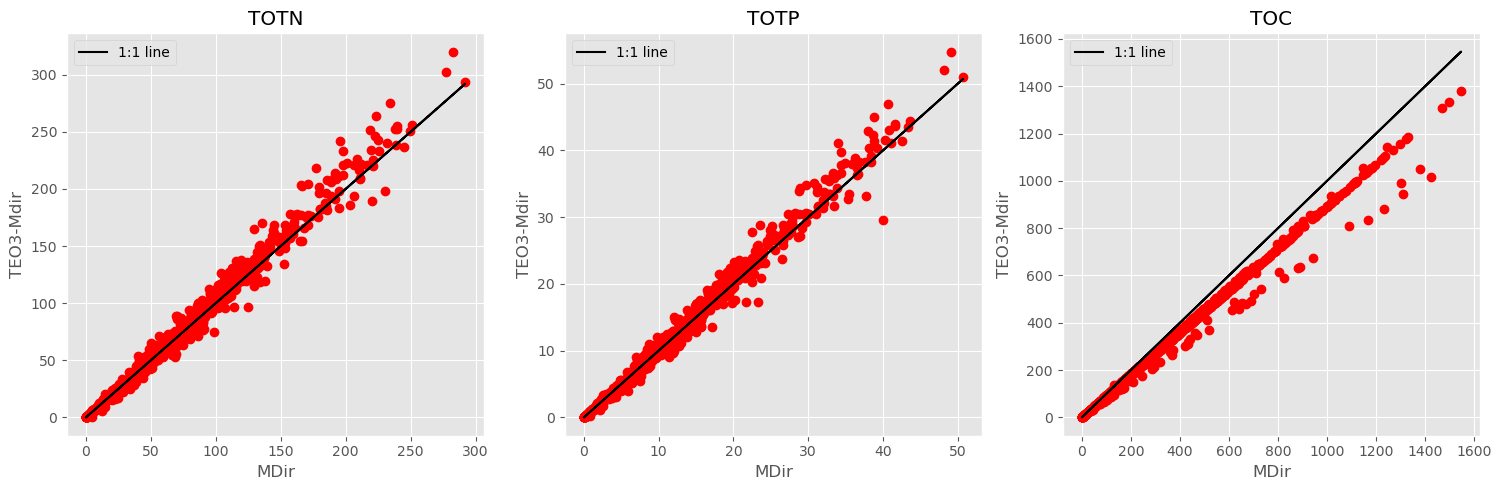

In [12]:
# Plot
y = "Mdir"

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
axes = axes.flatten()

for idx, par in enumerate(["TOTN", "TOTP", "TOC"]):
    axes[idx].plot(
        df_wide[f"{par}_tonnes_Mdir"], df_wide[f"{par}_tonnes_TEO3-{y}"], "ro"
    )
    axes[idx].plot(
        df_wide[f"{par}_tonnes_Mdir"],
        df_wide[f"{par}_tonnes_Mdir"],
        "k-",
        label="1:1 line",
    )
    axes[idx].set_xlabel("MDir")
    axes[idx].set_ylabel(f"TEO3-{y}")
    axes[idx].set_title(par)
    axes[idx].legend(loc="best")

plt.tight_layout()

At national scale:

 * TEOTIL3's estimated TOC losses are 11 % lower than the estimates from Mdir.
   
 * TEOTIL3's estimated losses of TOTN and TOTP are slightly higher than the estimates from Mdir (by 3 % and 2 %, respectively).

 * Results from TEOTIL3 and Mdir are generally in close agreement.

### 4.2. Between methods and datasets

In [13]:
print("TEOTIL3's estimates (using Fdir's data) as a percenatge of Mdir's estimates:")
teo_fdir_df.set_index("site_id").sum() / mdir_df.set_index("site_id").sum()

TEOTIL3's estimates (using Fdir's data) as a percenatge of Mdir's estimates:



TOC_tonnes     0.952427
TOTN_tonnes    1.106735
TOTP_tonnes    1.098243
dtype: float64

In [14]:
# Merge to long format
teo_fdir_df = teo_fdir_df.melt(id_vars="site_id", var_name="par")
teo_fdir_df["method"] = "TEO3-Fdir"

teo_mdir_df = teo_mdir_df.melt(id_vars="site_id", var_name="par")
teo_mdir_df["method"] = "TEO3-Mdir"

mdir_df = mdir_df.melt(id_vars="site_id", var_name="par")
mdir_df["method"] = "Mdir"

df_long = pd.concat(
    [
        teo_fdir_df,
        teo_mdir_df,
        mdir_df,
    ],
    axis="rows",
).reset_index(drop=True)

df_long.head()

,site_id,par,value,method
0,10029,TOC_tonnes,113.1785,TEO3-Fdir
1,10041,TOC_tonnes,128.0584,TEO3-Fdir
2,10045,TOC_tonnes,2.8226,TEO3-Fdir
3,10050,TOC_tonnes,24.8646,TEO3-Fdir
4,10054,TOC_tonnes,6.3864,TEO3-Fdir


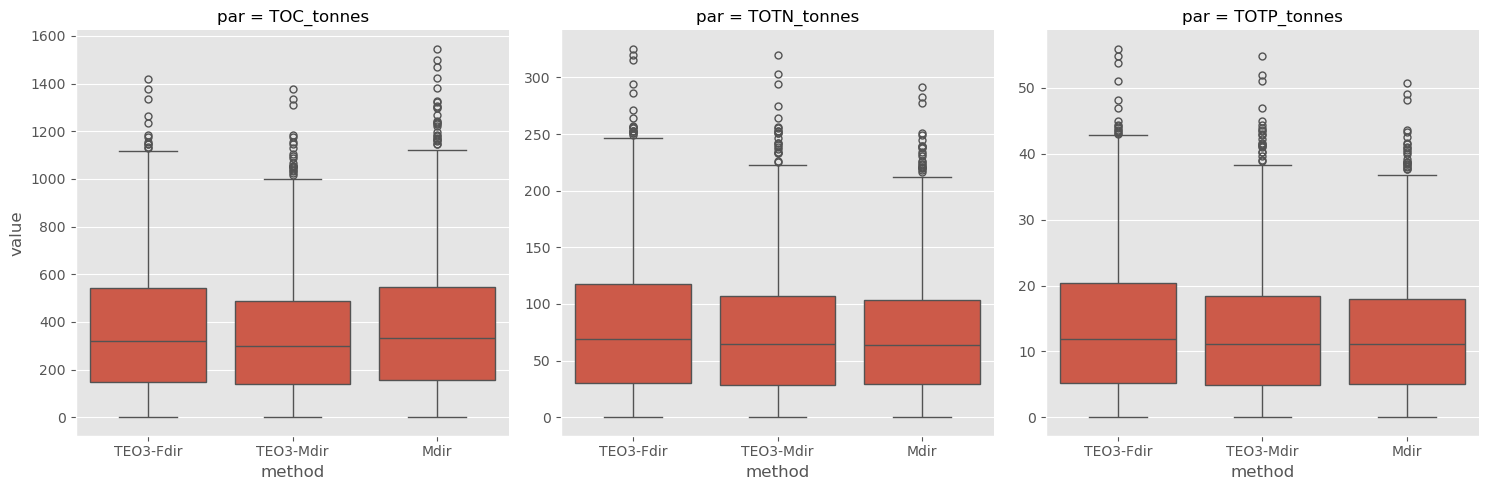

In [15]:
sn.catplot(
    data=df_long,
    x="method",
    y="value",
    col="par",
    sharex=False,
    sharey=False,
    kind="box",
)

Mdir's dataset seems to be missing some rows compared to Fdir's data. Losses of TOTN and TOTP estimated using Fdir's data are 11 % and 10 % higher, respectively, than the losses estimated by Mdir.

## 5. Identify missing rows

Identifying exactly which rows are missing in the Mdir dataset is not easy, because the encoding of `MERDID` is done differently in each dataset. The code cells below try to link them approximately.

In [16]:
def convert_to_int_as_str(x):
    try:
        ix = int(x)
        return str(ix)
    except Exception:
        return str(x)

In [17]:
# Read raw Fdir data
xl_path = (
    r"/home/jovyan/shared/common/teotil3/point_data/2023/fiske_oppdret_2023_raw.xlsx"
)
fdir_df = (
    pd.read_excel(xl_path, sheet_name="fiskeoppdrett_2023")
    .query("AAR == 2023")[["LOKNR", "MAANED", "MERDID"]]
    .drop_duplicates()
)
fdir_df["MERDID"] = fdir_df["MERDID"].apply(convert_to_int_as_str)

# Read raw Mdir data
xl_path = r"/home/jovyan/shared/common/teotil3/point_data/raw_data_delivered_2025/mdir_aqua_test/Merd - Akvakultur 16.12.2025.xlsx"
mdir_df = pd.read_excel(xl_path, sheet_name="Sheet1", skiprows=9).query("`År` == 2023")
link_df = pd.read_excel(link_xl_path, sheet_name="Spørring1")[
    ["AnleggNummer", "FiskeriLokNummer"]
]
mdir_df = pd.merge(mdir_df, link_df, how="left", on="AnleggNummer")[
    ["FiskeriLokNummer", "Måned", "Merdnr."]
].drop_duplicates()
mdir_df.columns = ["LOKNR", "MAANED", "MERDID"]
mdir_df["MERDID"] = mdir_df["MERDID"].apply(convert_to_int_as_str)

# Join
miss_df = fdir_df.merge(
    mdir_df, on=["LOKNR", "MAANED", "MERDID"], how="outer", indicator=True
).rename(columns={"_merge": "Dataset"})
miss_df["Dataset"] = miss_df["Dataset"].astype(str).replace(
    {"both": "Both", "left_only": "Fdir only", "right_only": "Mdir only"}
)

# Save
miss_df.to_excel("missing_mdir_data_approx.xlsx", index=False)